# Lab 02 — Análisis de resultados (nivel C)

Este notebook **no contiene lógica**: solo lee lo que generó `python main.py` en `results/` y muestra
tablas y figuras. Toda la implementación vive en `src/`.

In [1]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

RES = Path("..") / "results"
FIG = RES / "figures"
pd.set_option("display.float_format", "{:.4f}".format)
meta = json.loads((RES / "run_meta.json").read_text(encoding="utf-8"))
show = lambda name: display(Image(filename=str(FIG / name)))

## 1. Datos

Seis acciones líquidas, datos diarios ajustados. Auditoría: faltantes, duplicados, precios no
positivos, OHLC inconsistente, huecos y saltos máximos.

In [2]:
pd.read_csv(RES / "data_audit.csv", index_col=0)

,start,end,n_rows,n_nan,n_duplicated,n_nonpositive,n_bad_ohlc,max_gap_days,max_abs_return
ticker,,,,,,,,,
AAPL,2018-01-02,2026-09-30,2198,0,0,0,0,4,0.1533
MSFT,2018-01-02,2026-09-30,2198,0,0,0,0,4,0.1551
JPM,2018-01-02,2026-09-30,2198,0,0,0,0,4,0.1801
XOM,2018-01-02,2026-09-30,2198,0,0,0,0,4,0.1269
JNJ,2018-01-02,2026-09-30,2198,0,0,0,0,4,0.1004
WMT,2018-01-02,2026-09-30,2198,0,0,0,0,4,0.1171


## 2. Estrategia y regla de confirmación

Seis votos $v_{k,t}\in\{-1,0,+1\}$: ADX±DI (tendencia), RSI con zona de tolerancia (reversión),
desbalance de OBV (volumen), skew de retornos, autocorrelación de rezago 1 y z-score de volumen.

**RSI con zona de tolerancia:** entra a sobrecompra al pasar del nivel $L$ y sigue dentro mientras no
baje de $L-b$; tras $k$ días seguidos en la zona vota $-1$ (simétrico en sobreventa: $+1$). $L$, $b$ y
$k$ los elige Optuna.

Con $N^+_t$ y $N^-_t$ el número de votos a favor y en contra, la regla 3 de 6 es:

$$s_t = \mathbb{1}\{N^+_t \ge 3,\ N^+_t > N^-_t\} - \mathbb{1}\{N^-_t \ge 3,\ N^-_t > N^+_t\}, \qquad f_t = \frac{N^+_t - N^-_t}{6}$$

La señal de $t$ se ejecuta al open de $t+1$.

### Validación: correlación entre los votos (|ρ| < 0.5)

{
  "threshold": 0.5,
  "max_abs_train": 0.346855086289819,
  "max_abs_test": 0.40870031562765,
  "chosen_theta_max_window_corr": 0.6046107476478435,
  "vote_frequency": {
    "v_adx": 0.4749186783085088,
    "v_rsi": 0.031672658791302856,
    "v_obv": 0.6241225817497004,
    "v_skew": 0.46533127889060094,
    "v_autocorr": 0.03278548193802431,
    "v_volz": 0.14252696456086286
  },
  "signal_frequency": 0.1184728642355761
}
train


,v_adx,v_rsi,v_obv,v_skew,v_autocorr,v_volz
v_adx,1.0000,-0.1900,0.3500,0.1700,-0.0100,0.1100
v_rsi,-0.1900,1.0000,-0.1700,-0.1100,0.0000,-0.0700
v_obv,0.3500,-0.1700,1.0000,-0.0400,-0.0500,0.1600
v_skew,0.1700,-0.1100,-0.0400,1.0000,0.0200,0.0700
v_autocorr,-0.0100,0.0000,-0.0500,0.0200,1.0000,-0.0100
v_volz,0.1100,-0.0700,0.1600,0.0700,-0.0100,1.0000


test


,v_adx,v_rsi,v_obv,v_skew,v_autocorr,v_volz
v_adx,1.0000,-0.1900,0.4100,0.2300,-0.0100,0.0500
v_rsi,-0.1900,1.0000,-0.1400,-0.0400,-0.0000,0.0200
v_obv,0.4100,-0.1400,1.0000,0.0400,-0.0400,0.1300
v_skew,0.2300,-0.0400,0.0400,1.0000,0.0400,0.0700
v_autocorr,-0.0100,-0.0000,-0.0400,0.0400,1.0000,-0.0100
v_volz,0.0500,0.0200,0.1300,0.0700,-0.0100,1.0000


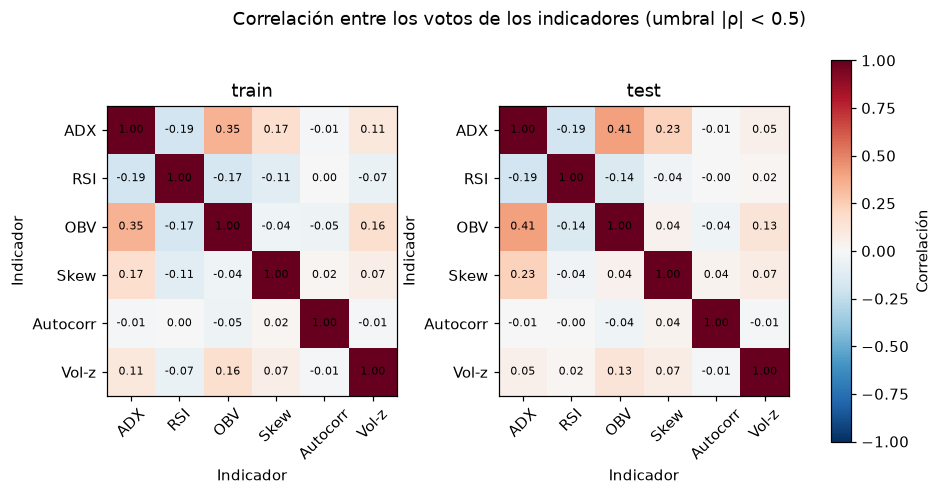

In [3]:
print(json.dumps(meta["vote_correlation"], indent=2))
for p in ["train", "test"]:
    print(p)
    display(pd.read_csv(RES / f"vote_correlation_{p}.csv", index_col=0).round(2))
show("17_vote_correlation.png")

### Pregunta 1 — 3 de 6 contra un solo indicador (θ promedio de cada activo)

In [4]:
conf = pd.read_csv(RES / "confirmation_vs_single.csv")
conf.pivot_table(index="rule", columns="period", values=["n_entries", "calmar"], aggfunc="median")

calmar         n_entries         
period      test   train      test    train
rule                                       
3 de 6   -0.0471 -0.0904   19.0000  39.0000
ADX      -0.0275  0.0433   36.0000  75.0000
AUTOCORR -0.2556 -0.0305   10.0000  24.5000
OBV      -0.1030 -0.0970   37.0000  77.5000
RSI      -0.0938  0.0049    2.5000   2.0000
SKEW      0.1093  0.0199   29.5000  57.5000
VOLZ     -0.0736 -0.1045   50.0000 121.0000

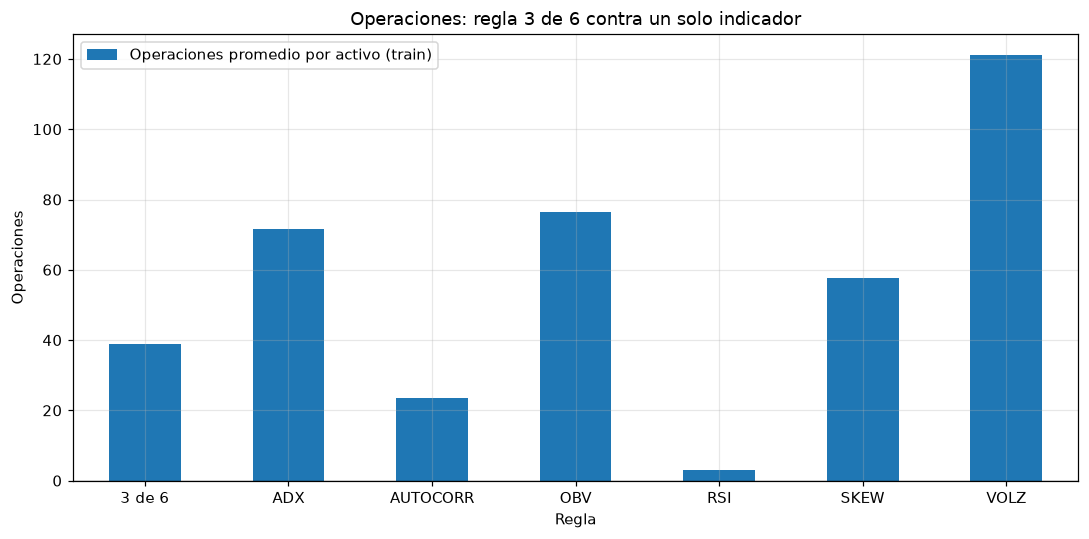

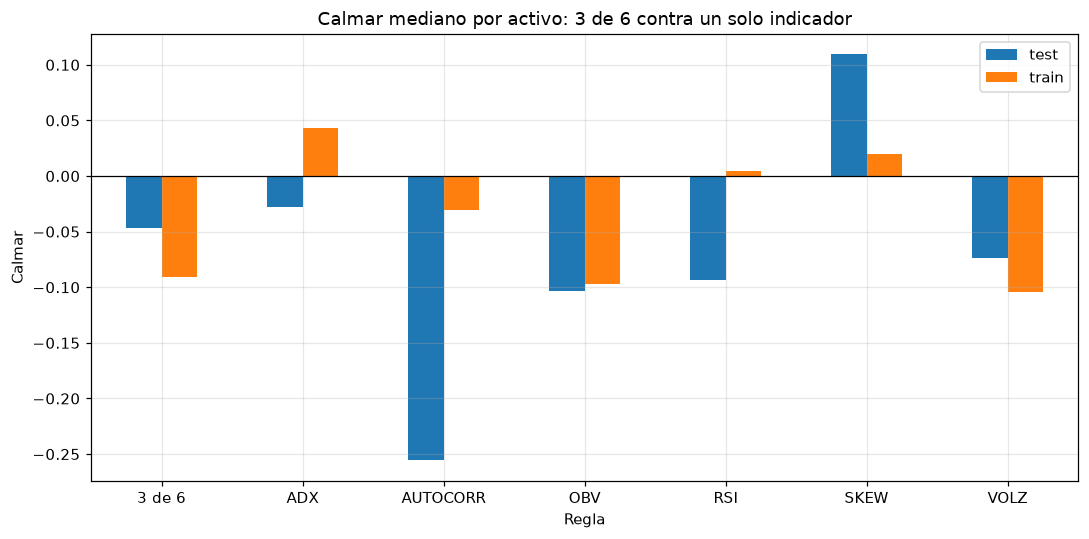

In [5]:
show("14_confirmation_trades.png"); show("15_confirmation_calmar.png")

## 3. Desempeño fuera de muestra

*train* (2019–2023): walk-forward, cada mes se opera con parámetros optimizados en los 6 meses
anteriores. *test* (2024-01 → 2026-09): para cada activo y régimen se promedian los θ del walk-forward
y se congelan.

In [6]:
perf = pd.read_csv(RES / "performance.csv", index_col=[0, 1])
cols = ["total_return", "annual_return", "sharpe", "sortino", "calmar", "max_drawdown", "win_rate", "n_trades", "turnover", "total_costs"]
perf[cols]

total_return  annual_return  sharpe  sortino  \
strategy                 period                                                 
Risk Parity              train        -0.0602        -0.0124 -0.2390  -0.3215   
                         test          0.1690         0.0588  1.0344   1.8530   
                         total         0.0986         0.0123  0.2645   0.3960   
Risk Parity naive (1/σ)  train        -0.0786        -0.0163 -0.3219  -0.4319   
                         test          0.1625         0.0566  0.9996   1.7924   
                         total         0.0712         0.0089  0.2001   0.2991   
Pesos iguales            train        -0.0710        -0.0147 -0.2749  -0.3737   
                         test          0.1611         0.0561  0.9850   1.7761   
                         total         0.0787         0.0099  0.2139   0.3218   
Buy & hold equiponderado train         1.6723         0.2178  1.0813   1.5691   
                         test          0.8777         0.2592  1.8975   2.9174   
                         total         4.0179         0.2323  1.2631   1.8505   
Activo AAPL              train        -0.2621        -0.0591 -0.5023  -0.6380   
                         test         -0.2494        -0.0996 -1.1561  -1.5873   
                         total        -0.4461        -0.0737 -0.6980  -0.9034   
Activo MSFT              train         0.0571         0.0112  0.1741   0.2493   
                         test          0.2562         0.0870  1.1454   1.9180   
                         total         0.3280         0.0374  0.4923   0.7356   
Activo JPM               train         0.1687         0.0317  0.3088   0.4599   
                         test         -0.2141        -0.0843 -1.0719  -1.3860   
                         total        -0.0815        -0.0110 -0.0413  -0.0598   
Activo XOM               train        -0.0172        -0.0035  0.0242   0.0354   
                         test          0.0261         0.0095  0.1896   0.2702   
                         total         0.0084         0.0011  0.0593   0.0863   
Activo JNJ               train        -0.1649        -0.0355 -0.6027  -0.8050   
                         test          0.2087         0.0718  1.0509   1.5895   
                         total         0.0094         0.0012  0.0504   0.0709   
Activo WMT               train        -0.2152        -0.0474 -0.5528  -0.7240   
                         test          0.1169         0.0413  0.4753   0.6406   
                         total        -0.1235        -0.0169 -0.1537  -0.2038   

                                 calmar  max_drawdown  win_rate  n_trades  \
strategy                 period                                             
Risk Parity              train  -0.0975        0.1270    0.4363  204.0000   
                         test    1.5981        0.0368    0.4805   77.0000   
                         total   0.0954        0.1285    0.4484  281.0000   
Risk Parity naive (1/σ)  train  -0.1197        0.1359    0.4265  204.0000   
                         test    1.4514        0.0390    0.4805   77.0000   
                         total   0.0645        0.1387    0.4413  281.0000   
Pesos iguales            train  -0.1080        0.1356    0.4265  204.0000   
                         test    1.3554        0.0414    0.4805   77.0000   
                         total   0.0725        0.1359    0.4413  281.0000   
Buy & hold equiponderado train   0.7406        0.2941       NaN    0.0000   
                         test    1.5573        0.1664       NaN    0.0000   
                         total   0.7898        0.2941       NaN    0.0000   
Activo AAPL              train  -0.1459        0.4053    0.4242   33.0000   
                         test   -0.3970        0.2509    0.1765   17.0000   
                         total  -0.1469        0.5015    0.3400   50.0000   
Activo MSFT              train   0.0581        0.1926    0.4667   30.0000   
                         test    0.9157        0.0950 

### Walk-forward y θ congelado

Cobertura del walk-forward por clasificador y régimen (ventanas, uso del θ global y estudios sin
θ factible) y θ promedio que se congela para el periodo de prueba.

In [7]:
wf = pd.read_csv(RES / "wf_params.csv")
wf.groupby(["method", "regime"]).agg(ventanas=("window", "nunique"), usa_theta_global=("fallback", "mean"),
                                     sin_theta_factible=("infeasible", "mean")).round(3)

ventanas  usa_theta_global  sin_theta_factible
method regime                                                        
hmm    crisis                60            0.5830              0.0330
       mean_reversion        60            0.3500              0.0670
       trend                 60            0.4670              0.0330
kmeans crisis                60            0.6640              0.0140
       mean_reversion        60            0.1390              0.0220
       trend                 60            0.4970              0.0140
none   global                60            0.0000              0.0110
rules  crisis                60            0.8110              0.0280
       mean_reversion        60            0.1860              0.0360
       trend                 60            0.2580              0.0250

In [8]:
theta = json.loads((RES / "theta_averaged.json").read_text(encoding="utf-8"))
pd.DataFrame(theta).T.rename_axis("activo|régimen")

,adx_window,adx_threshold,rsi_window,rsi_level,rsi_tol,rsi_k,obv_window,obv_threshold,feat_window,autocorr_window,atr_window,sl_mult,tp_mult,max_holding,position_frac
activo|régimen,,,,,,,,,,,,,,,
AAPL|global,14.0000,23.5161,17.0000,75.7162,4.9560,6.0000,17.0000,0.1464,19.0000,53.0000,18.0000,2.6284,3.5443,23.0000,0.5591
AAPL|trend,15.0000,25.0282,18.0000,76.5708,5.1510,5.0000,20.0000,0.1493,27.0000,54.0000,19.0000,2.4087,3.8057,29.0000,0.6308
AAPL|mean_reversion,16.0000,24.1542,18.0000,75.7355,4.9992,6.0000,18.0000,0.1739,20.0000,58.0000,18.0000,2.4972,3.8948,28.0000,0.6216
AAPL|crisis,19.0000,22.6346,19.0000,75.1337,5.1128,5.0000,22.0000,0.1744,21.0000,45.0000,20.0000,2.6372,3.6007,30.0000,0.6629
JNJ|global,15.0000,22.4304,16.0000,75.1921,4.4554,5.0000,18.0000,0.1199,23.0000,52.0000,18.0000,2.3152,3.4844,20.0000,0.5948
JNJ|trend,18.0000,24.8814,17.0000,73.9464,4.5545,5.0000,14.0000,0.1578,22.0000,54.0000,19.0000,2.7364,3.6501,35.0000,0.6327
JNJ|mean_reversion,17.0000,22.5657,20.0000,74.8994,4.2225,5.0000,15.0000,0.1879,22.0000,56.0000,17.0000,2.4752,3.7849,30.0000,0.6411
JNJ|crisis,16.0000,23.2072,16.0000,76.1099,4.8935,6.0000,17.0000,0.1142,22.0000,52.0000,19.0000,2.0947,3.9531,29.0000,0.5966
JPM|global,14.0000,21.2991,17.0000,73.4178,4.7640,5.0000,18.0000,0.1218,21.0000,58.0000,19.0000,2.5068,3.5748,24.0000,0.6267


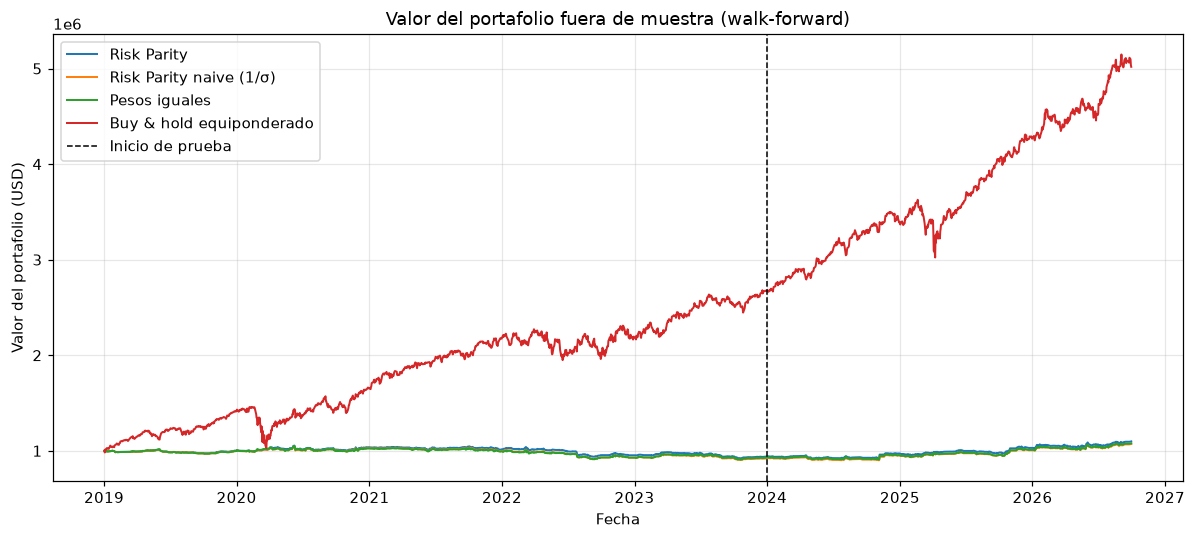

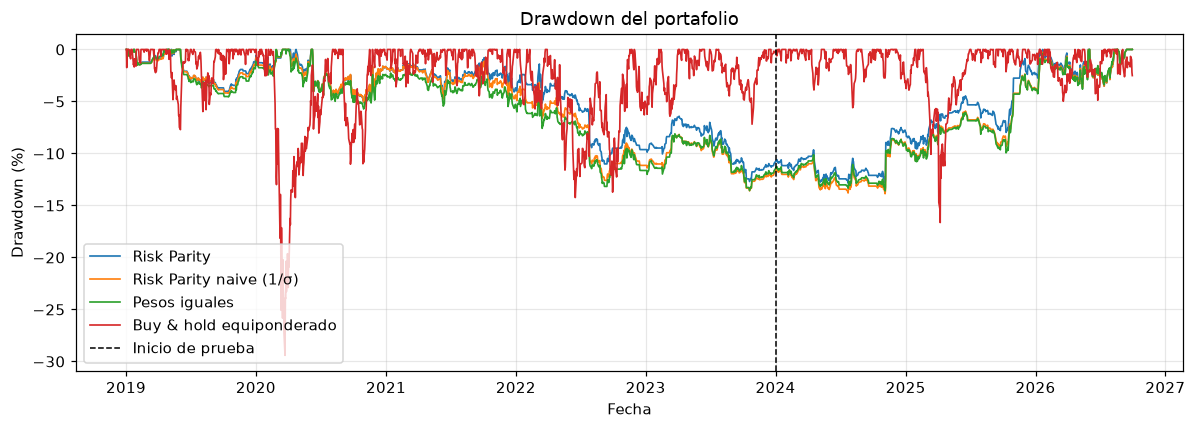

In [9]:
show("01_equity.png"); show("02_drawdown.png")

### Lista de operaciones del portafolio Risk Parity

In [10]:
trades = pd.read_csv(RES / "trades_rp.csv", parse_dates=["entry_date", "exit_date"])
display(trades.groupby(["ticker", "exit_reason"]).size().unstack(fill_value=0))
trades.tail(10)

exit_reason,signal,stop_loss,take_profit
ticker,,,
AAPL,12,28,10
JNJ,14,17,13
JPM,19,22,12
MSFT,17,9,12
WMT,22,17,14
XOM,16,16,11


,ticker,side,entry_date,exit_date,entry_price,exit_price,pnl,exit_reason
271,JPM,SHORT,2026-03-12,2026-04-08,280.1280,306.5888,-12283.6658,stop_loss
272,JNJ,SHORT,2026-02-23,2026-04-14,239.7734,232.5194,1374.4616,signal
273,AAPL,SHORT,2026-03-23,2026-04-17,253.5176,267.0601,-9120.0729,stop_loss
274,MSFT,LONG,2026-04-16,2026-06-01,418.1654,463.9666,32573.9699,take_profit
275,AAPL,LONG,2026-06-01,2026-06-09,309.3632,295.6678,-9204.5614,stop_loss
276,AAPL,SHORT,2026-06-26,2026-07-01,274.7630,293.1872,-18851.8137,stop_loss
277,WMT,SHORT,2026-05-27,2026-07-13,118.0474,114.4560,6506.5077,signal
278,MSFT,LONG,2026-07-31,2026-08-10,449.1545,506.2244,13470.0041,take_profit
279,JPM,LONG,2026-07-10,2026-08-12,337.4700,363.5377,16951.2817,take_profit
280,XOM,LONG,2026-07-29,2026-09-14,156.7053,168.7000,12187.4026,signal


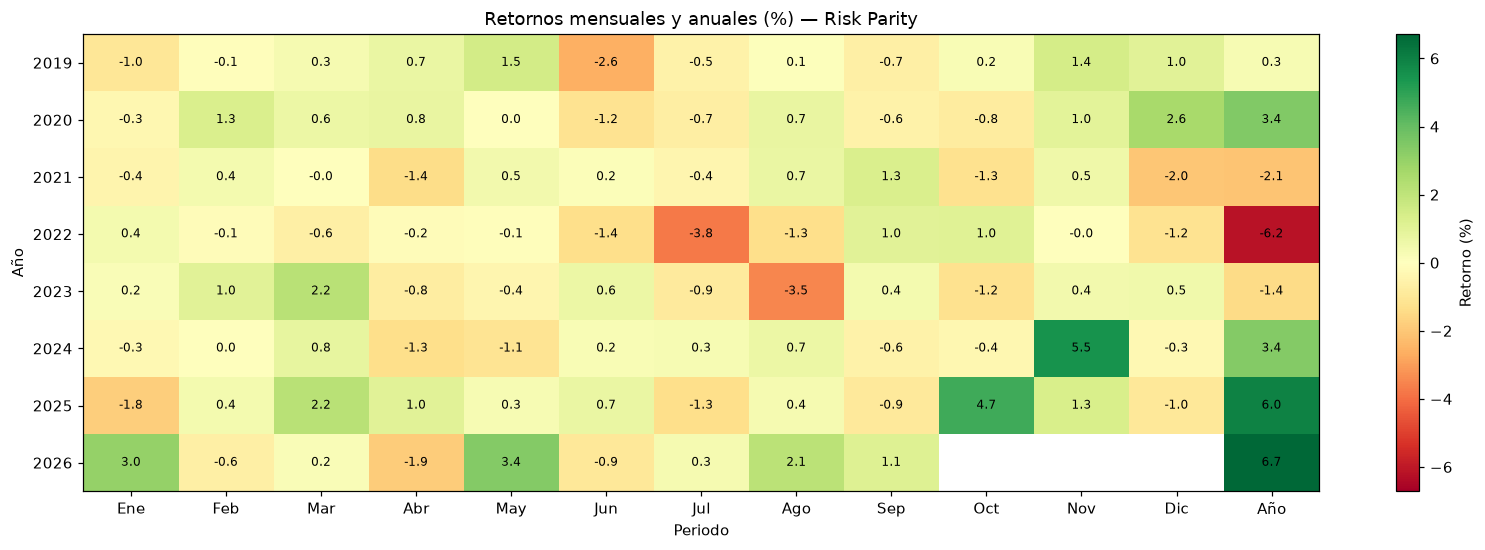

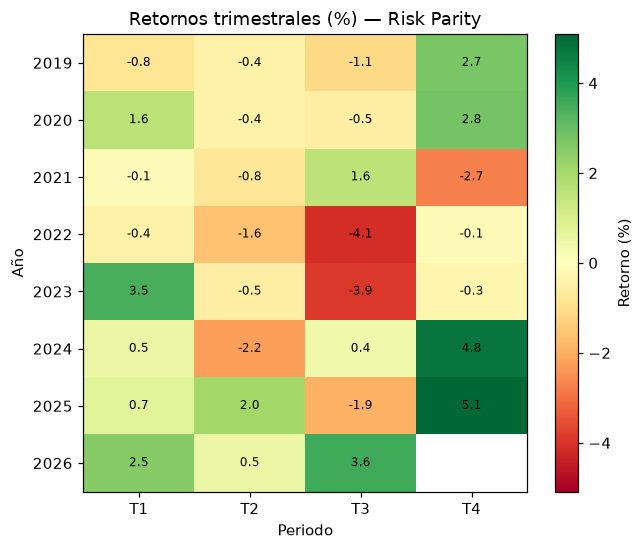

In [11]:
show("03_monthly_returns_rp.png"); show("03b_quarterly_returns_rp.png")

In [12]:
print("Exposición bruta promedio:", meta["avg_gross_exposure"])
print("Exposición bruta máxima al cierre:", meta["max_gross_exposure_close"])
print("Salidas del portafolio RP:", meta["rp_exit_reasons"])

Exposición bruta promedio: {'rp': 0.21134898309266026, 'naive': 0.2095729859269948, 'ew': 0.21065219280149672}
Exposición bruta máxima al cierre: {'rp': 0.8550910693457612, 'naive': 0.8562061955299103, 'ew': 0.8555215877579769}
Salidas del portafolio RP: {'stop_loss': 109, 'signal': 100, 'take_profit': 72}


### Pregunta 2 — Degradación entre entrenamiento y prueba en el walk-forward

In [13]:
deg = pd.read_csv(RES / "wf_degradation.csv")
print(json.dumps(meta["degradation"], indent=2))
deg.groupby("period")[["is_calmar", "oos_calmar", "is_annual_return", "oos_annual_return"]].median()

{
  "train": {
    "median_is_calmar": 5.9663371613059475,
    "median_oos_calmar": 0.0,
    "mean_is_annual_return": 0.1744478997854228,
    "mean_oos_annual_return": 0.0280976794662501
  }
}


,is_calmar,oos_calmar,is_annual_return,oos_annual_return
period,,,,
train,5.9663,0.0000,0.1316,0.0000


### Defecto del Calmar con retorno negativo

Con $R<0$, $\text{Calmar}=R/\text{MDD}$ se acerca a 0 cuando el MDD crece: maximizarlo puede preferir
perder más con un drawdown mayor. Solo actúa cuando todas las configuraciones de un estudio pierden.
Se repitieron con su semilla original todos los estudios donde el mejor Calmar fue negativo
(detalle en `docs/hallazgo_calmar.md`).

In [14]:
print(json.dumps(meta["calmar_negative_audit"], indent=2))
audit = pd.read_csv(RES / "calmar_audit.csv")
audit[["ticker", "window", "method", "regime", "best_R", "best_mdd", "least_loss_R", "least_loss_mdd",
       "mdd_percentile_of_best", "picked_least_loss"]].sort_values("picked_least_loss")

{
  "n_studies": 2176,
  "n_best_calmar_negative": 163,
  "share_best_calmar_negative": 0.07490808823529412,
  "all_reproduce": true,
  "mean_mdd_percentile_of_best_among_losers": 0.287522461361645,
  "mean_corr_calmar_mdd_among_losers": -0.15750301233814398,
  "n_picked_least_loss": 99,
  "n_picked_bigger_loss": 64,
  "share_of_all_studies_affected": 0.029411764705882353,
  "median_extra_loss_when_affected": 0.0144174064976344,
  "median_extra_mdd_when_affected": 0.02420715344766572
}


,ticker,window,method,regime,best_R,best_mdd,least_loss_R,least_loss_mdd,mdd_percentile_of_best,picked_least_loss
0,AAPL,1,rules,crisis,-0.1578,0.0822,-0.0336,0.0168,0.9744,False
96,WMT,31,hmm,mean_reversion,-0.0088,0.0214,-0.0078,0.0182,0.0625,False
95,WMT,31,kmeans,mean_reversion,-0.0040,0.0157,-0.0032,0.0094,0.5918,False
93,WMT,28,rules,mean_reversion,-0.0350,0.0358,-0.0263,0.0242,0.4865,False
91,XOM,31,hmm,crisis,-0.0280,0.0733,-0.0218,0.0522,0.2432,False
...,...,...,...,...,...,...,...,...,...,...
82,MSFT,27,rules,mean_reversion,-0.0064,0.0422,-0.0064,0.0422,0.0000,True
161,WMT,58,hmm,trend,-0.0219,0.0210,-0.0219,0.0210,0.1200,True
79,AAPL,28,none,global,-0.0014,0.0512,-0.0014,0.0512,0.0000,True
22,JNJ,6,hmm,trend,-0.0447,0.0300,-0.0447,0.0300,0.0000,True


### Pregunta 3 — Sensibilidad a ±20% de los parámetros

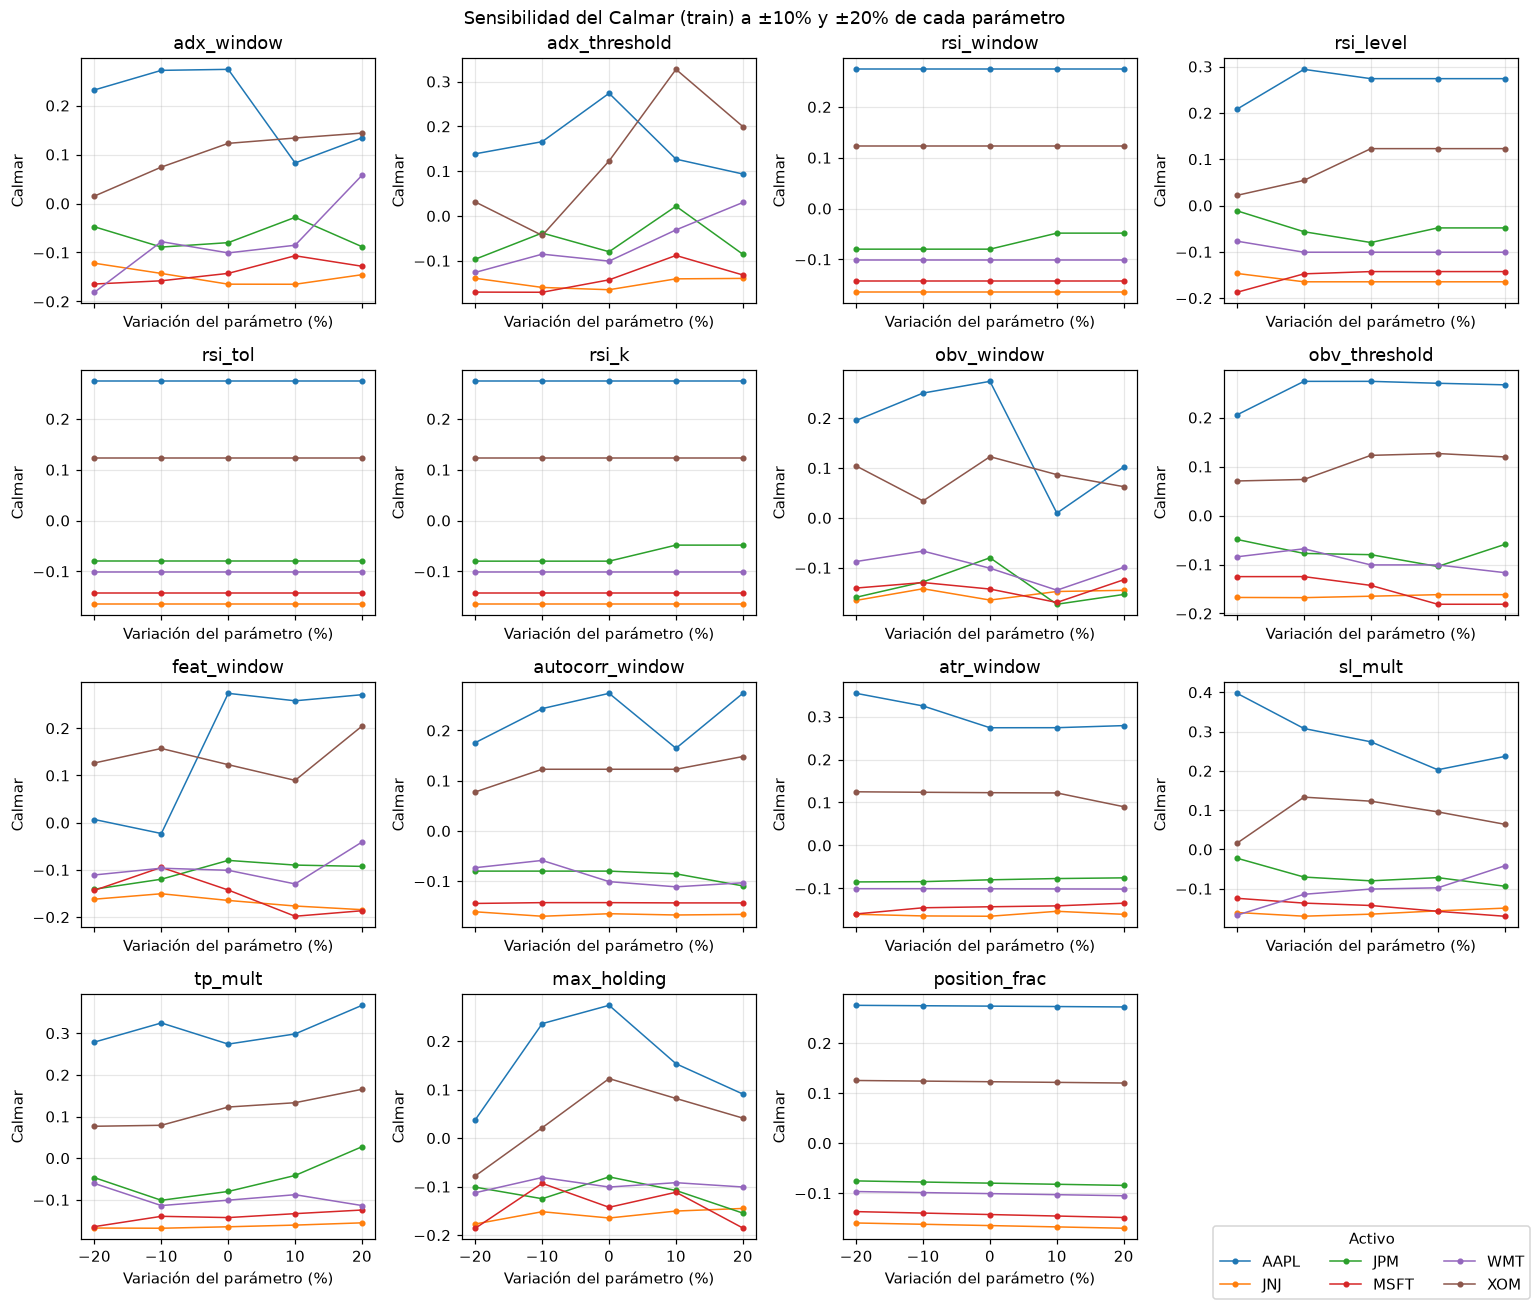

param
sl_mult           0.0474
max_holding       0.0430
adx_window        0.0372
tp_mult           0.0274
adx_threshold     0.0265
rsi_level         0.0209
obv_window        0.0191
obv_threshold     0.0172
feat_window       0.0161
atr_window        0.0048
position_frac     0.0044
autocorr_window   0.0031
rsi_k             0.0000
rsi_tol           0.0000
rsi_window        0.0000
Name: d_calmar, dtype: float64

In [15]:
show("04_sensitivity.png")
sens = pd.read_csv(RES / "sensitivity.csv")
base = sens[sens.delta == 0].set_index(["ticker", "param"])["calmar"]
sens["d_calmar"] = sens["calmar"] - sens.set_index(["ticker", "param"]).index.map(base)
# cambio absoluto: varios activos tienen Calmar base negativo, así que el cociente no tiene sentido
sens[sens.delta.abs() == 0.2].groupby("param")["d_calmar"].agg(lambda v: v.abs().median()).sort_values(ascending=False)

### Pregunta 4 — Costo de transacción de equilibrio

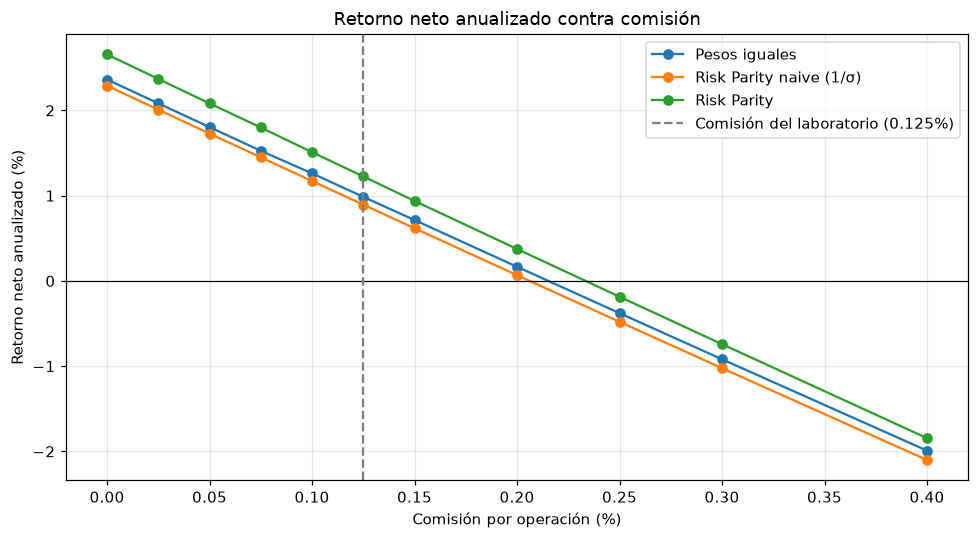

Método de régimen: hmm
Comisión de equilibrio: {'ew': 0.0021521712414049824, 'naive': 0.002061281043993825, 'rp': 0.002333948296273145}


method,ew,naive,rp
commission,,,
0.0000,0.0236,0.0229,0.0266
0.0003,0.0208,0.0201,0.0237
0.0005,0.0180,0.0173,0.0208
0.0008,0.0153,0.0145,0.0180
0.0010,0.0126,0.0117,0.0151
0.0013,0.0099,0.0089,0.0123
0.0015,0.0071,0.0062,0.0094
0.0020,0.0017,0.0007,0.0037
0.0025,-0.0038,-0.0048,-0.0019


In [16]:
show("05_cost_curve.png")
print("Método de régimen:", meta["regime_method"])
print("Comisión de equilibrio:", meta["breakeven_commission"])
pd.read_csv(RES / "cost_sweep.csv").pivot(index="commission", columns="method", values="annual_return_total")

## 4. Régimen de mercado: tres clasificadores

Variables en ventana móvil de 63 días sobre el índice equiponderado: volatilidad, razón de
eficiencia y autocorrelación de rezago 1. Tres clasificadores, todos re-ajustados cada mes solo con
historia pasada y con histéresis de 3 días:

- **Reglas:** crisis si vol $> q_{0.90}$; tendencia si eficiencia $>$ mediana; reversión en otro caso.
- **K-means** de 3 clusters sobre las variables estandarizadas.
- **HMM gaussiano** operado con la etiqueta **filtrada** $\hat s_t=\arg\max_j P(S_t=j\mid x_1,\dots,x_t)$
  (algoritmo forward). Viterbi resuelve $\arg\max P(S_{1..T}\mid x_{1..T})$ y re-etiqueta el pasado con
  el futuro, así que solo se muestra como comparación; usarlo para operar invalidaría el backtest.

El método que se opera se elige **solo con train** (mayor Calmar del portafolio Risk Parity en
2019–2023), nunca con test.

In [17]:
val = json.loads((RES / "regime_validation.json").read_text(encoding="utf-8"))
print("Método elegido:", val["selected_method"], "| regla:", val["selection_rule"])
print("Calmar train por método:", val["train_calmar_by_method"])
print("HMM: desacuerdo filtrada vs Viterbi en train:", round(val["hmm_train_viterbi_disagreement"], 4))
rows = {}
for m, v in val["methods"].items():
    rows[m] = {"silhouette (train)": v["train_fit"]["silhouette"],
               "duración media train (días)": v["train_fit"]["avg_duration_days"],
               "transiciones/año train": v["train_fit"]["transitions_per_year"],
               "duración media causal operada (días)": v["causal_operated"]["avg_duration_days"],
               "transiciones/año causal operada": v["causal_operated"]["transitions_per_year"],
               **{f"% {r} test": v["causal_operated"]["share_test"].get(r, 0.0) for r in ["trend", "mean_reversion", "crisis"]}}
pd.DataFrame(rows).T

Método elegido: hmm | regla: max Calmar del portafolio RP en train (2019-2023)
Calmar train por método: {'rules': -0.13668028794739415, 'kmeans': -0.1512459672484954, 'hmm': -0.0974535335968604}
HMM: desacuerdo filtrada vs Viterbi en train: 0.0166


,silhouette (train),duración media train (días),transiciones/año train,duración media causal operada (días),transiciones/año causal operada,% trend test,% mean_reversion test,% crisis test
rules,0.2945,13.3796,18.6602,34.2586,7.2290,0.6836,0.2293,0.0871
kmeans,0.3754,14.5960,17.0907,34.2586,7.2290,0.5472,0.4528,0.0000
hmm,0.2534,120.4167,1.9183,82.7917,2.9170,0.8679,0.0914,0.0406


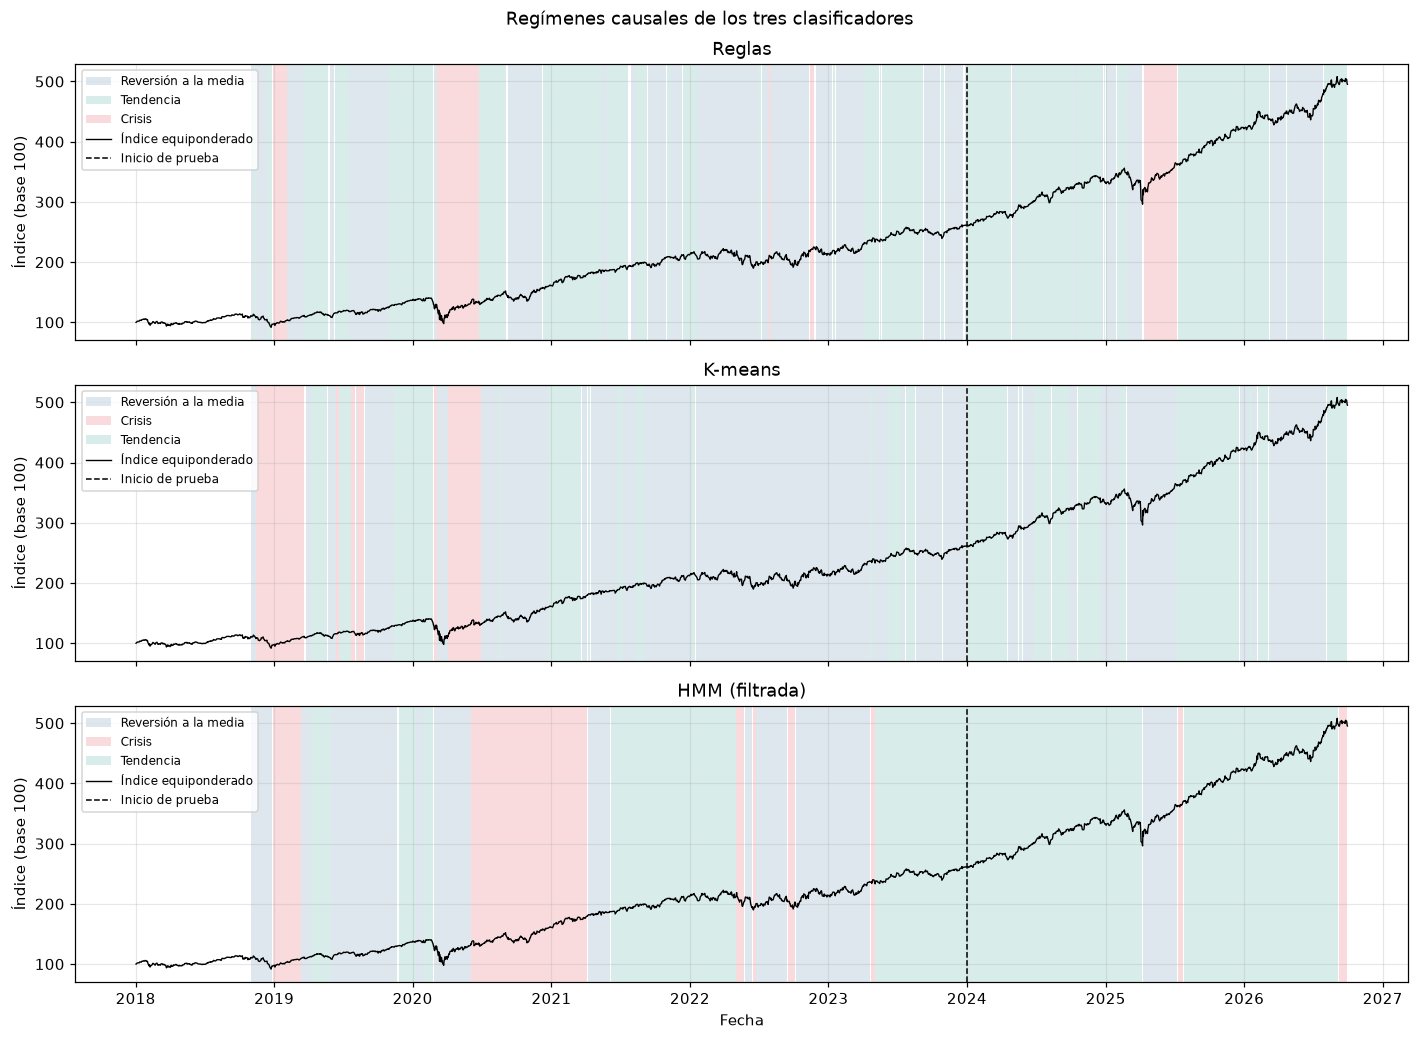

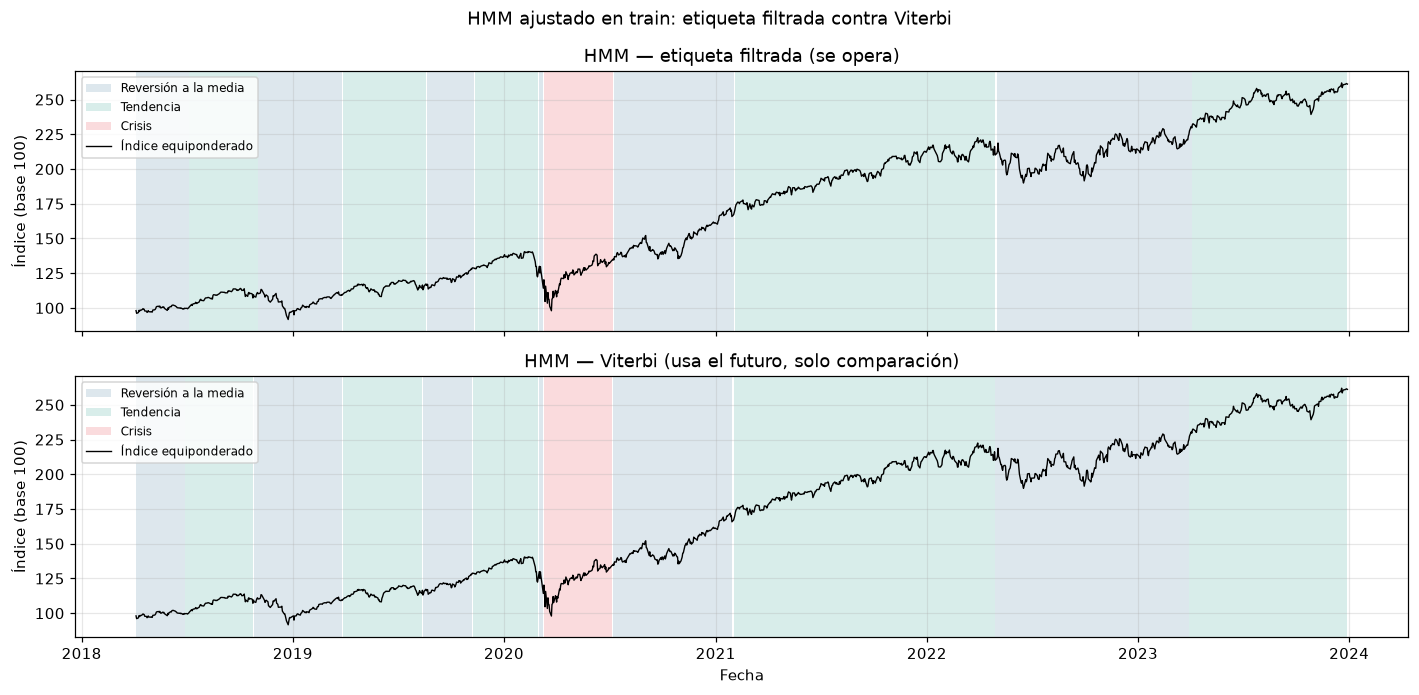

In [18]:
show("06b_regime_methods.png"); show("06c_hmm_filtered_vs_viterbi.png")

### Comparación: θ por régimen (3 clasificadores) contra el modelo sin régimen y buy & hold

Portafolio Risk Parity con las mismas señales base, costos y rebalanceo; solo cambia el
clasificador de régimen (o su ausencia). *Sin régimen* usa el θ global de cada ventana y no aplica
reglas ni multiplicadores por régimen.

In [19]:
comp = pd.read_csv(RES / "regime_method_comparison.csv", index_col=[0, 1])
comp[["total_return", "annual_return", "sharpe", "sortino", "calmar", "max_drawdown", "win_rate", "n_trades"]]

total_return  annual_return  sharpe  sortino  \
strategy                 period                                                 
Régimen · Reglas         train        -0.0544        -0.0112 -0.2618  -0.3818   
                         test         -0.0679        -0.0254 -0.5113  -0.6848   
                         total        -0.1186        -0.0162 -0.3597  -0.5041   
Régimen · K-means        train        -0.1197        -0.0252 -0.5011  -0.6649   
                         test         -0.0035        -0.0013 -0.0025  -0.0035   
                         total        -0.1228        -0.0168 -0.3251  -0.4373   
Régimen · HMM (filtrada) train        -0.0602        -0.0124 -0.2390  -0.3215   
                         test          0.1690         0.0588  1.0344   1.8530   
                         total         0.0986         0.0123  0.2645   0.3960   
Sin régimen              train        -0.1601        -0.0344 -0.5234  -0.7119   
                         test         -0.0847        -0.0318 -0.5720  -0.7817   
                         total        -0.2312        -0.0335 -0.5376  -0.7321   
Buy & hold equiponderado train         1.6723         0.2178  1.0813   1.5691   
                         test          0.8777         0.2592  1.8975   2.9174   
                         total         4.0179         0.2323  1.2631   1.8505   

                                 calmar  max_drawdown  win_rate  n_trades  
strategy                 period                                            
Régimen · Reglas         train  -0.1367        0.0816    0.4140  215.0000  
                         test   -0.3023        0.0840    0.4074   81.0000  
                         total  -0.1211        0.1339    0.4122  296.0000  
Régimen · K-means        train  -0.1512        0.1668    0.4045  220.0000  
                         test   -0.0169        0.0765    0.4578   83.0000  
                         total  -0.0913        0.1841    0.4191  303.0000  
Régimen · HMM (filtrada) train  -0.0975        0.1270    0.4363  204.0000  
                         test    1.5981        0.0368    0.4805   77.0000  
                         total   0.0954        0.1285    0.4484  281.0000  
Sin régimen              train  -0.1782        0.1928    0.4388  278.0000  
                         test   -0.1881        0.1693    0.4513  113.0000  
                         total  -0.1328        0.2520    0.4425  391.0000  
Buy & hold equiponderado train   0.7406        0.2941       NaN    0.0000  
                         test    1.5573        0.1664       NaN    0.0000  
                         total   0.7898        0.2941       NaN    0.0000

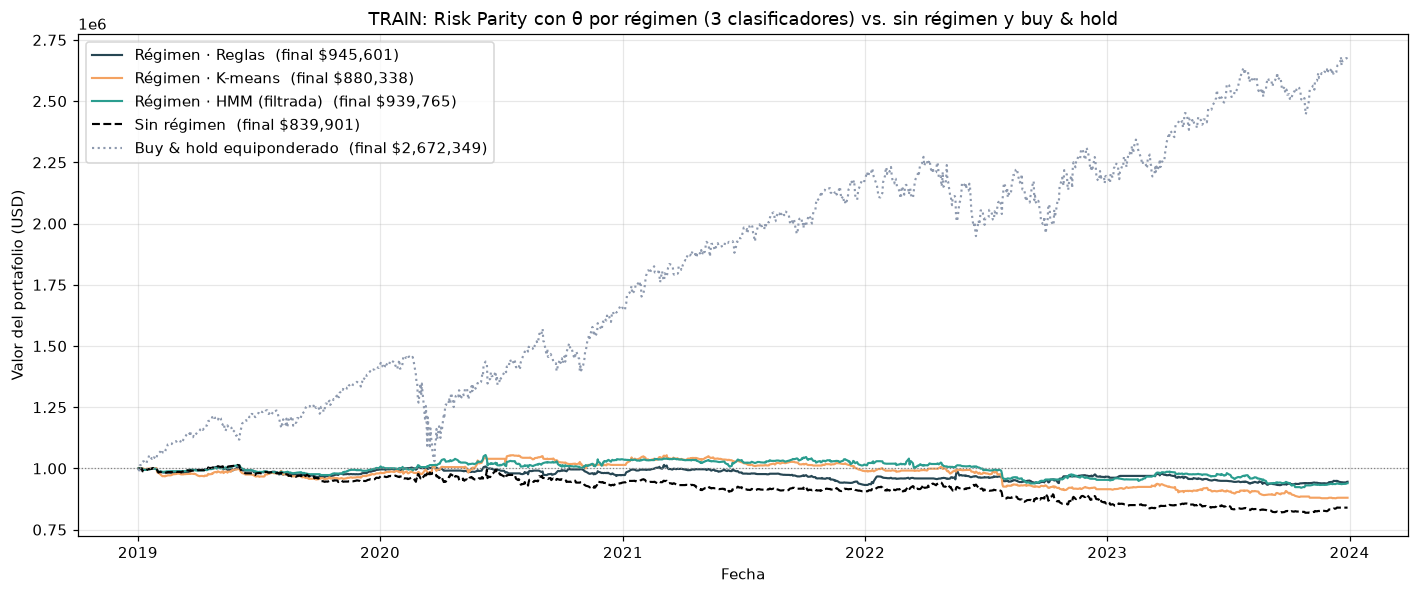

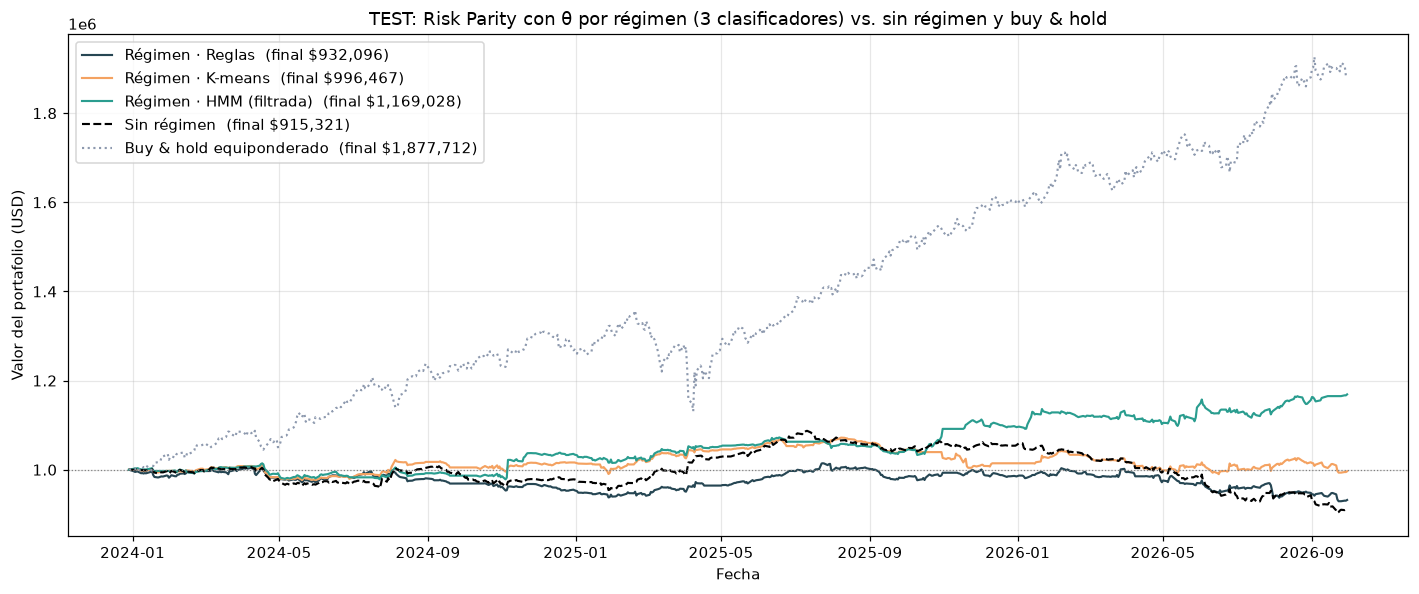

In [20]:
show("16_regime_methods_train.png"); show("16_regime_methods_test.png")

### Método elegido: línea de tiempo, distribuciones y portafolio

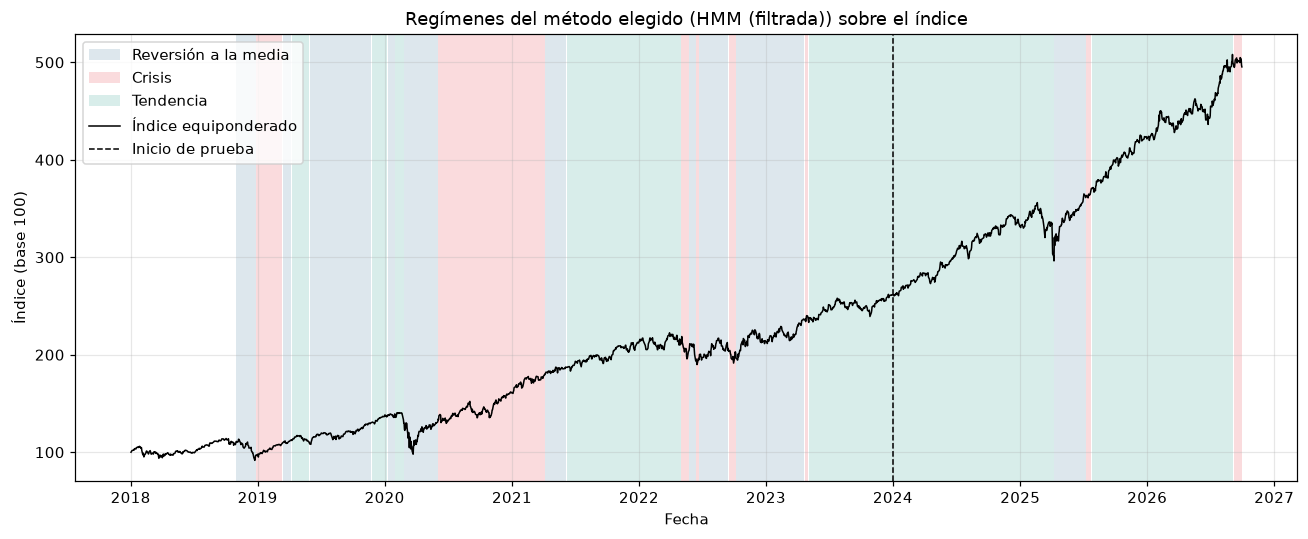

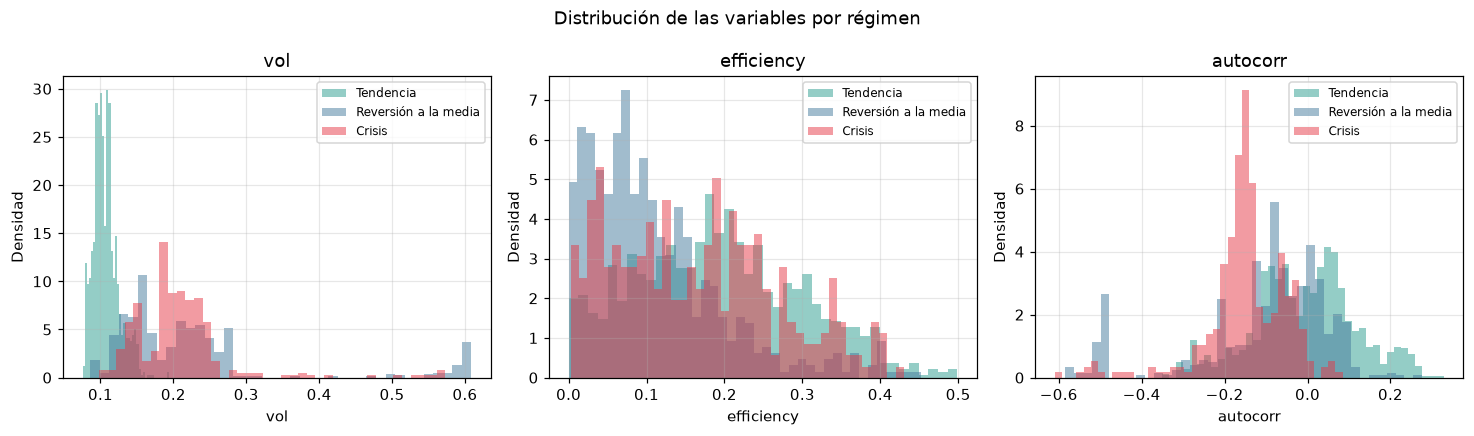

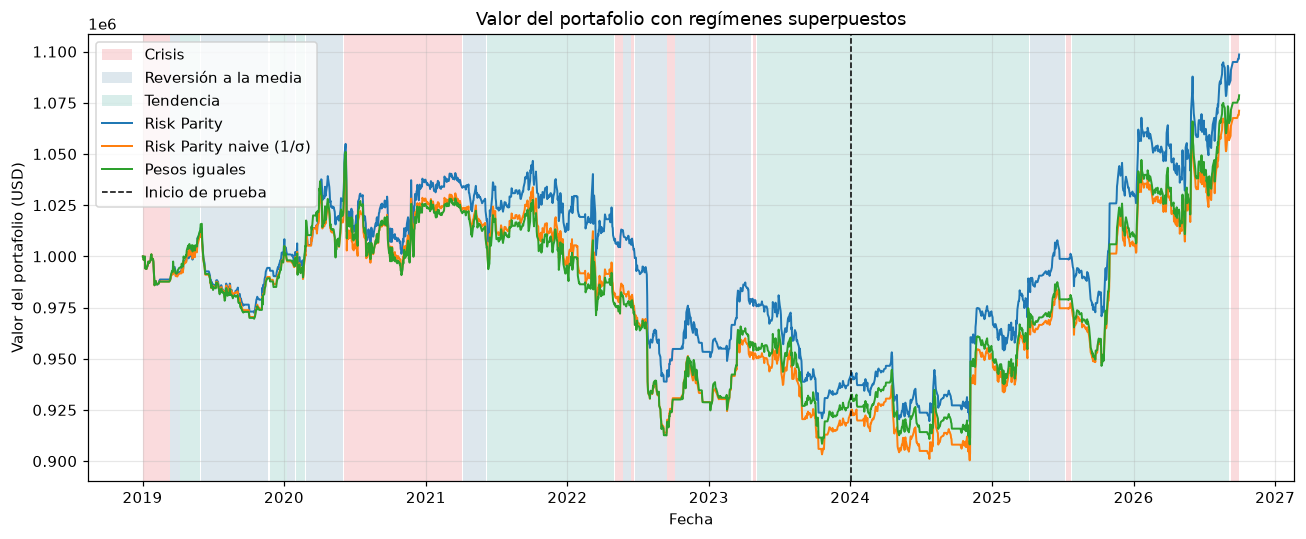

In [21]:
show("06_regime_timeline.png"); show("07_regime_distributions.png"); show("08_equity_regimes.png")

### Pregunta 5 — ¿Difiere el desempeño entre regímenes?

In [22]:
for name in ["rp", "naive", "ew", "bh"]:
    print(name, "p-value Kruskal-Wallis:", round(meta["kruskal_pvalue_by_regime"][name], 4))
    display(pd.read_csv(RES / f"metrics_by_regime_{name}.csv", index_col=0))

rp p-value Kruskal-Wallis: 0.6407


,days,mean_daily,annual_vol,sharpe,sortino,cum_return,hit_rate
crisis,332.0000,0.0000,0.0542,0.1315,0.1821,0.0075,0.4608
mean_reversion,537.0000,-0.0001,0.0380,-0.3428,-0.4654,-0.0289,0.3911
trend,1077.0000,0.0001,0.0554,0.5176,0.8177,0.1229,0.4605


naive p-value Kruskal-Wallis: 0.4282


,days,mean_daily,annual_vol,sharpe,sortino,cum_return,hit_rate
crisis,332.0000,0.0000,0.0545,0.0973,0.1344,0.0050,0.4669
mean_reversion,537.0000,-0.0001,0.0391,-0.4991,-0.6802,-0.0423,0.3892
trend,1077.0000,0.0001,0.0549,0.4828,0.7620,0.1128,0.4643


ew p-value Kruskal-Wallis: 0.5131


,days,mean_daily,annual_vol,sharpe,sortino,cum_return,hit_rate
crisis,332.0000,-0.0000,0.0551,-0.0428,-0.0588,-0.0051,0.4639
mean_reversion,537.0000,-0.0001,0.0425,-0.3504,-0.4920,-0.0331,0.3873
trend,1077.0000,0.0001,0.0556,0.5092,0.8097,0.1213,0.4624


bh p-value Kruskal-Wallis: 0.3512


,days,mean_daily,annual_vol,sharpe,sortino,cum_return,hit_rate
crisis,332.0000,0.0012,0.1858,1.6137,2.3325,0.4508,0.5542
mean_reversion,537.0000,0.0013,0.2553,1.2603,1.9020,0.8517,0.5493
trend,1077.0000,0.0006,0.1188,1.2902,1.7942,0.8678,0.5673


## 5. Portafolio: tres formas de asignación

- Pesos iguales $w_i = 1/n$.
- Risk Parity naive $w_i = \dfrac{1/\sigma_i}{\sum_j 1/\sigma_j}$ (ignora correlaciones).
- Risk Parity por minimización (`scipy.optimize.minimize`): $\min_y \tfrac12 y^\top\Sigma y - \sum_i b_i\ln y_i$,
  $w_i = y_i/\sum_j y_j$, que da $RC_i = w_i(\Sigma w)_i/\sigma_p$ iguales. Covarianza Ledoit-Wolf de 126 días.

### Pregunta 6

In [23]:
pd.read_csv(RES / "risk_contributions.csv", index_col=0)

,Risk Parity,Risk Parity naive (1/σ),Pesos iguales
AAPL,0.1290,0.1425,0.1593
MSFT,0.1828,0.1867,0.1980
JPM,0.1640,0.1625,0.1611
XOM,0.1469,0.1515,0.1617
JNJ,0.1901,0.1848,0.1606
WMT,0.1871,0.1720,0.1593


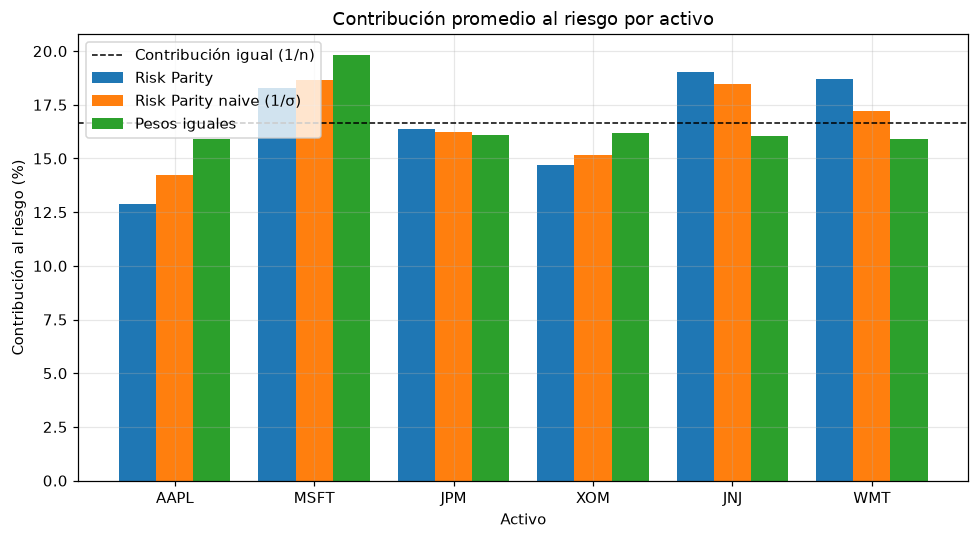

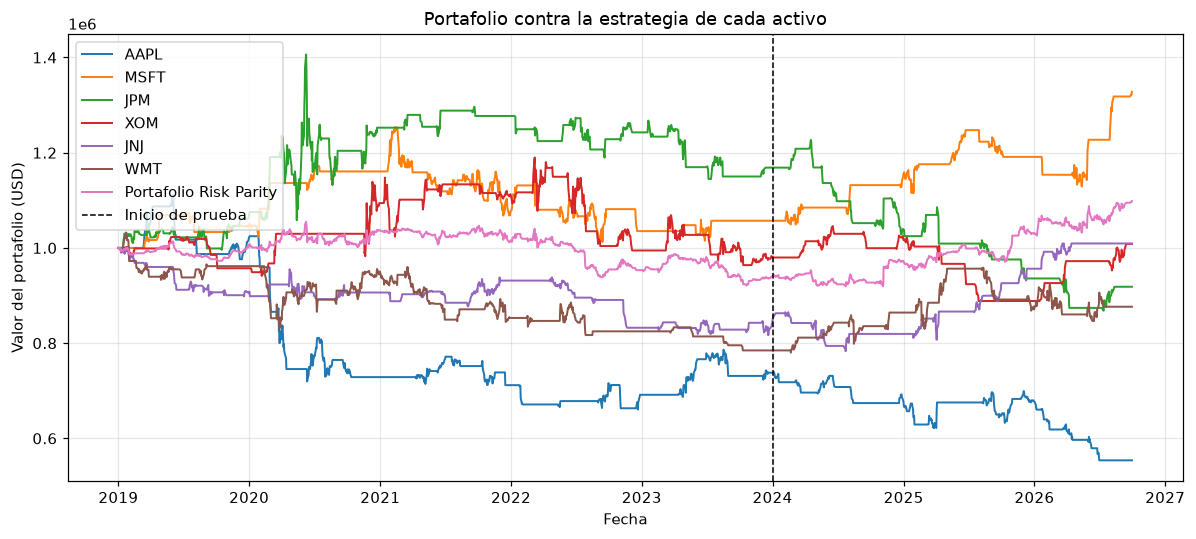

In [24]:
show("09_risk_contributions.png"); show("13_assets_vs_portfolio.png")

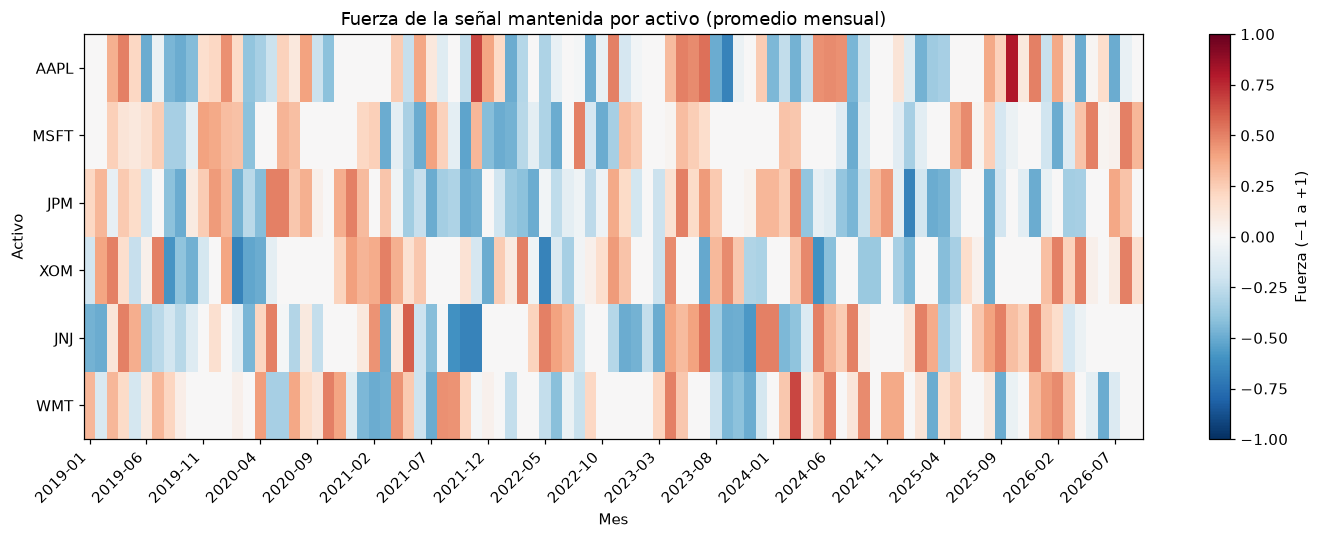

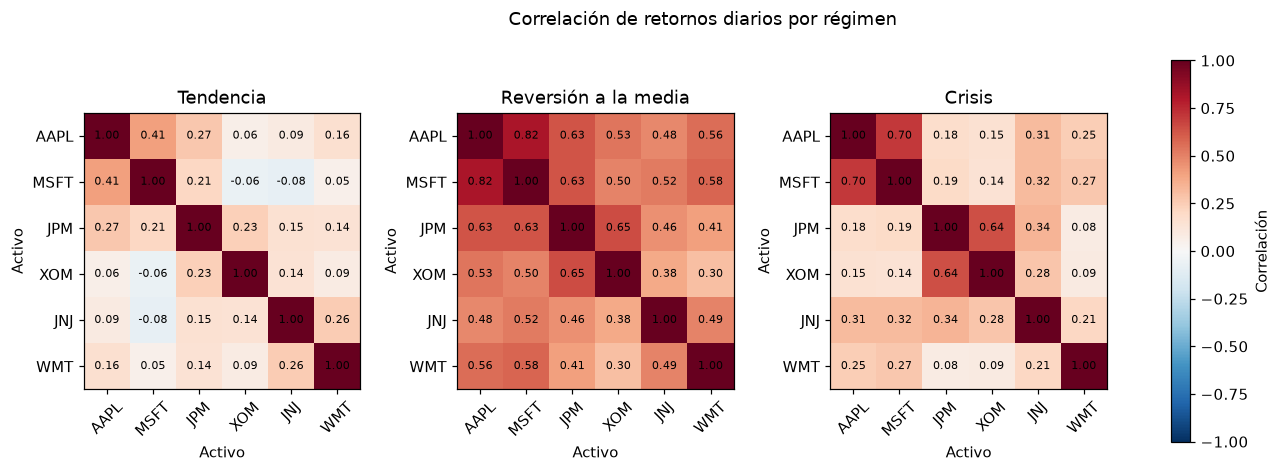

In [25]:
show("10_signal_heatmap.png"); show("11_correlation_regimes.png")

### Rebalanceo y rotación

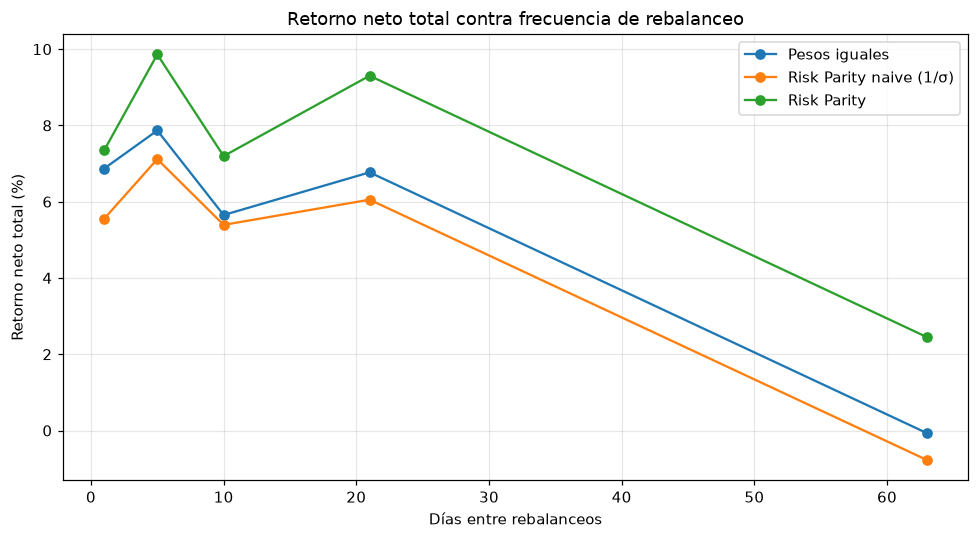

,every,method,annual_return,calmar,turnover,total_costs,gross_return,net_return
0,1,rp,0.0092,0.0614,12.3222,115427.1413,0.1889,0.0735
1,1,naive,0.0070,0.0452,12.0272,111560.9927,0.1671,0.0555
2,1,ew,0.0086,0.0567,12.0415,112442.9349,0.1811,0.0687
3,5,rp,0.0123,0.0954,11.2119,107643.0982,0.2063,0.0986
4,5,naive,0.0089,0.0645,10.9908,103748.7344,0.1749,0.0712
5,5,ew,0.0099,0.0725,10.9222,103317.5516,0.1820,0.0787
6,10,rp,0.0090,0.0693,10.4631,99910.1432,0.1719,0.0720
7,10,naive,0.0068,0.0502,10.3018,97076.7190,0.1510,0.0539
8,10,ew,0.0071,0.0529,10.3277,97329.5462,0.1538,0.0565
9,21,rp,0.0116,0.0876,10.1007,97282.9884,0.1903,0.0930


In [26]:
show("12_rebalance_sweep.png")
pd.read_csv(RES / "rebalance_sweep.csv")

## 6. Limitación de ejecución: impacto de mercado estimado

El backtest asume ejecución completa al precio modelado. Estimación con la ley de raíz cuadrada
$\text{impacto} \approx \sigma_{diaria}\sqrt{Q/V}$ por ejecución (no cobrada en el backtest).

In [27]:
meta["market_impact"]

{'median_participation': 3.613930643218226e-05,
 'max_participation': 0.0005258982256503026,
 'impact_cost_total': 9932.350359681477,
 'impact_cost_annual_pct_equity': 0.0012931721390370247,
 'commission_total': 107643.0981587926}

In [28]:
{k: meta.get(k) for k in ["n_windows", "n_configs_evaluated", "n_studies_infeasible", "wf_minutes", "wf_minutes_note", "test_protocol", "seed"]}

{'n_windows': 60,
 'n_configs_evaluated': 227400,
 'n_studies_infeasible': 102,
 'wf_minutes': 53.300000000000004,
 'wf_minutes_note': 'minutos de cómputo; 2 de 8 bloques se alargaron por suspensión de la máquina y se estimaron con la mediana de los bloques completos',
 'test_protocol': 'theta promedio del walk-forward de train, congelado',
 'seed': 42}